## Gravando um vídeo usando OpenCV
Ao desenvolver aplicações, torna-se importante salvar vídeos de demonstração do seu trabalho, já que muitas aplicações em si podem exigir o salvamento de um videoclipe. Por exemplo, em uma aplicação de vigilância, você pode precisar salvar um videoclipe assim que detectar algo incomum.

Neste notebook, descreveremos como salvar um vídeo nos formatos **avi** e **mp4** usando OpenCV.

## Leia o vídeo da fonte

In [1]:
# import the library
import cv2
import matplotlib.pyplot as plt
%matplotlib inline


source = './race_car.mp4'  # source = 0 for webcam

cap = cv2.VideoCapture(source)

In [2]:
if (cap.isOpened()== False): 
  print("Error opening video stream or file")

### <font color="green">Ler e exibir um quadro</font>

In [3]:
ret, frame = cap.read()

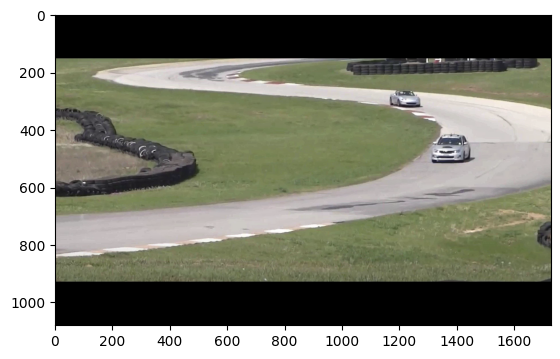

In [4]:
plt.imshow(frame[...,::-1])

### <font color="green">Exibir o vídeo do arquivo</font>

In [5]:
from IPython.display import HTML
HTML("""
<video width=1024 controls>
  <source src="race_car.mp4" type="video/mp4">
</video>
""")

## Gravar Vídeo usando OpenCV
Para gravar o vídeo, você precisa criar um objeto VideoWriter com os parâmetros corretos.

### <font color="green">Sintaxe da Função</font>
```python
Objeto VideoWriter = cv.VideoWriter(nome_do_arquivo, fourcc, fps, tamanho_do_quadro)
```
Onde,
**Parâmetros**

1. `nome_do_arquivo`: Nome do arquivo de vídeo de saída.

2. `fourcc`: Código de 4 caracteres do codec usado para comprimir os quadros. Por exemplo, VideoWriter::fourcc('P','I','M','1') é um codec MPEG-1, VideoWriter::fourcc('M','J','P','G') é um codec motion-jpeg etc. A lista de códigos pode ser obtida na página Video Codecs by FOURCC. O backend FFMPEG com contêiner MP4 usa nativamente outros valores como código fourcc: consulte ObjectType, portanto, você pode receber uma mensagem de aviso do OpenCV sobre a conversão do código fourcc.
3. `fps`: Taxa de quadros do fluxo de vídeo criado.
4. `frameSize`: Tamanho dos quadros de vídeo.

In [6]:
# Default resolutions of the frame are obtained.
# Convert the resolutions from float to integer.
frame_width = int(cap.get(3))
frame_height = int(cap.get(4))

# Define the codec and create VideoWriter object.
out_avi = cv2.VideoWriter('race_car_out.avi',cv2.VideoWriter_fourcc('M','J','P','G'), 10, (frame_width,frame_height))

out_mp4 = cv2.VideoWriter('race_car_out.mp4',cv2.VideoWriter_fourcc(*'XVID'), 10, (frame_width,frame_height))

### <font color="green">Ler frames e gravar em arquivo</font>
Vamos ler os frames do vídeo do carro de corrida e gravá-los nos dois objetos que criamos na etapa anterior. Devemos liberar os objetos após a conclusão da tarefa.

In [7]:
# Read until video is completed
while(cap.isOpened()):
  # Capture frame-by-frame
  ret, frame = cap.read()
    
  if ret == True:
    
    # Write the frame to the output files
    out_avi.write(frame)
    out_mp4.write(frame)
    
  # Break the loop
  else: 
    break

In [8]:
# When everything done, release the VideoCapture and VideoWriter objects
cap.release()
out_avi.release()
out_mp4.release()